# Peak tourism months exploration

Scatterplot of `data/processed/PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv`
(see `data/scripts/compute_peak_tourism_indicator.py`) -- every
(country, month) row in the table, not just each country's single peak
month. Countries on the Y axis, sorted north-to-south by capital latitude
(see `data/reference/tourist_cities.json`); calendar month (1-12) on the
X axis. Marker color encodes `PEAK_RATIO` (how busy that month is
relative to the country's own peak, 0-1); marker size encodes
`PASSENGERS` (sqrt-scaled, so a small country isn't invisible next to a
large one), i.e. the underlying market's actual volume for that signal --
see data/README.md for what `PASSENGERS` means per country. Costa Rica
(hotel occupancy %) and Canada (aircraft movements, not people) don't
have a headcount in `PASSENGERS`, so both are drawn at one fixed size
instead of a misleading scaled one. Each country's actual peak month
(`PEAK_RATIO == 1.0`) is outlined in red so the peak-season pattern is
easy to read at a glance.

Run `data/scripts/compute_peak_tourism_indicator.py` first if
`PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv` doesn't exist yet or is stale.
Run `data/scripts/multiple/fetch_tourist_cities.py` first if
`tourist_cities.json` doesn't exist yet or is stale.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Notebook lives in notebooks/, data lives in ../data/
DATA_DIR = Path("..") / "data" / "processed"
PEAK_TOURISM_PATH = DATA_DIR / "PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv"

peak_tourism = pd.read_csv(PEAK_TOURISM_PATH)
peak_tourism.head()

,COUNTRY,MONTH,PEAK_RATIO,COUNTRY_NAME,SOURCE_YEAR,PASSENGERS
0,AT,1,0.6193,Austria,2026,2317970.0
1,AT,2,0.6266,Austria,2026,2345124.0
2,AT,3,0.7109,Austria,2026,2660638.0
3,AT,4,0.7461,Austria,2026,2792404.0
4,AT,5,0.8315,Austria,2025,3111959.0


## Sort countries by capital latitude for the Y axis

In [2]:
import json

# Capital latitude per country, from data/reference/tourist_cities.json
# (built by fetch_tourist_cities.py) -- replaces the old alphabetical sort
# so the Y axis reads roughly north-to-south geographically instead.
# PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv and tourist_cities.json spell a
# couple of names differently; NAME_ALIASES bridges those.
TOURIST_CITIES_PATH = Path("..") / "data" / "reference" / "tourist_cities.json"
NAME_ALIASES = {"Türkiye": "Turkey"}

with open(TOURIST_CITIES_PATH, encoding="utf-8") as f:
    tourist_cities = json.load(f)["cities"]

# A few countries have more than one "primary" capital tagged in the
# source (e.g. Netherlands: Amsterdam is the constitutional capital, The
# Hague is the seat of government) -- keep the most populous one per
# country so the choice is deterministic rather than depending on row order.
capitals_by_country = {}
for city in tourist_cities:
    if city.get("capital") != "primary":
        continue
    country = city["country"]
    current = capitals_by_country.get(country)
    if current is None or (city["population"] or 0) > (current["population"] or 0):
        capitals_by_country[country] = city

capital_lat = {}
for country_name in peak_tourism["COUNTRY_NAME"].unique():
    lookup_name = NAME_ALIASES.get(country_name, country_name)
    capital = capitals_by_country.get(lookup_name)
    capital_lat[country_name] = capital["lat"] if capital else None

missing_capitals = [name for name, lat in capital_lat.items() if lat is None]
if missing_capitals:
    print(f"WARNING: no capital latitude found for: {missing_capitals} -- sorted last (treated as lat=-90).")

# North -> south top-to-bottom. Matplotlib's categorical y-axis plots
# position 0 at the BOTTOM, so the list is reversed before assigning
# positions -- position 0 becomes the southernmost capital (bottom of the
# chart), and the highest position becomes the northernmost (top).
countries_top_to_bottom = sorted(
    capital_lat, key=lambda c: capital_lat[c] if capital_lat[c] is not None else -90, reverse=True
)
countries_bottom_to_top = list(reversed(countries_top_to_bottom))
country_to_y = {country: i for i, country in enumerate(countries_bottom_to_top)}

peak_tourism["y"] = peak_tourism["COUNTRY_NAME"].map(country_to_y)
peak_tourism[["COUNTRY_NAME", "MONTH", "PEAK_RATIO", "y"]].head()

All countries resolved a capital latitude.

,COUNTRY_NAME,MONTH,PEAK_RATIO,y
0,Austria,1,0.6193,28
1,Austria,2,0.6266,28
2,Austria,3,0.7109,28
3,Austria,4,0.7461,28
4,Austria,5,0.8315,28


## Scale dot size by PASSENGERS (fixed size for Costa Rica & Canada)

In [3]:
import numpy as np

# Dot size encodes each row's PASSENGERS value (sqrt-scaled -- area should
# scale with volume, not radius) instead of PEAK_RATIO, so the chart shows
# both how big a market is (size) and how seasonal it is (color). Costa
# Rica (hotel occupancy %), Canada (aircraft movements, not people), and
# Brazil (share of annual visits, %) don't have a real headcount in
# PASSENGERS, so scaling them the same way would be misleading -- all
# three get one fixed size instead. Chile's PASSENGERS is overnight stays
# rather than air passengers, but it's still a genuine headcount-adjacent
# volume, so it's scaled like every other country.
FIXED_SIZE_COUNTRIES = {"Costa Rica", "Canada", "Brazil"}
FIXED_SIZE = 110  # same rough midpoint as the old PEAK_RATIO*160+30 scheme
MIN_SIZE, MAX_SIZE = 20, 500

scalable = peak_tourism[~peak_tourism["COUNTRY_NAME"].isin(FIXED_SIZE_COUNTRIES)]
sqrt_passengers = np.sqrt(scalable["PASSENGERS"].astype(float))
lo, hi = sqrt_passengers.min(), sqrt_passengers.max()

def marker_size(row):
    if row["COUNTRY_NAME"] in FIXED_SIZE_COUNTRIES:
        return FIXED_SIZE
    scaled = (np.sqrt(float(row["PASSENGERS"])) - lo) / (hi - lo)
    return MIN_SIZE + scaled * (MAX_SIZE - MIN_SIZE)

peak_tourism["MARKER_SIZE"] = peak_tourism.apply(marker_size, axis=1)
peak_tourism[["COUNTRY_NAME", "MONTH", "PASSENGERS", "MARKER_SIZE"]].head()

,COUNTRY_NAME,MONTH,PASSENGERS,MARKER_SIZE
0,Austria,1,2317970.0,136.661798
1,Austria,2,2345124.0,137.507627
2,Austria,3,2660638.0,146.998001
3,Austria,4,2792404.0,150.793768
4,Austria,5,3111959.0,159.642929


## Scatterplot: every (country, month) observation

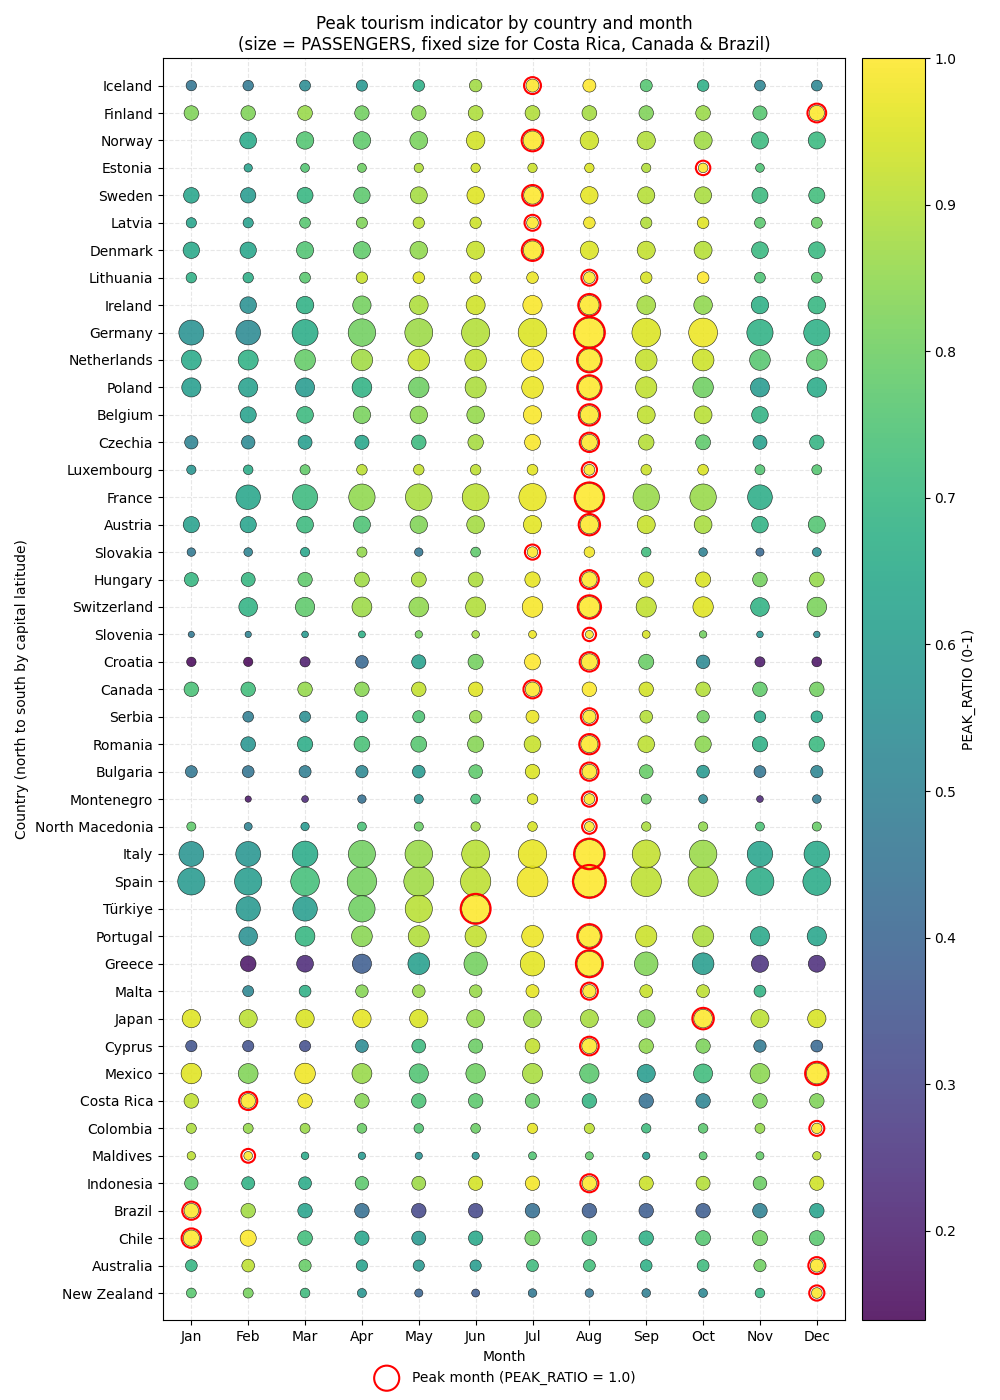

In [4]:
fig, ax = plt.subplots(figsize=(10, 14))

scatter = ax.scatter(
    peak_tourism["MONTH"],
    peak_tourism["y"],
    c=peak_tourism["PEAK_RATIO"],
    s=peak_tourism["MARKER_SIZE"],
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.4,
    zorder=2,
)

# Outline each country's actual peak month (PEAK_RATIO == 1.0) in red so
# the peak-season pattern reads clearly against the rest of the year.
peak_months = peak_tourism[peak_tourism["PEAK_RATIO"] == 1.0]
ax.scatter(
    peak_months["MONTH"],
    peak_months["y"],
    facecolors="none",
    edgecolors="green",
    linewidths=1.5,
    s=peak_months["MARKER_SIZE"] + 60,
    zorder=3,
    label="Peak month (PEAK_RATIO = 1.0)",
)

ax.set_yticks(range(len(countries_bottom_to_top)))
ax.set_yticklabels(countries_bottom_to_top)
ax.set_ylim(-1, len(countries_bottom_to_top))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlim(0.5, 12.5)

ax.set_xlabel("Month")
ax.set_ylabel("Country")
ax.set_title("Peak tourism indicator by country and month\n(size = PASSENGERS, fixed size for Costa Rica & Canada)")
ax.grid(axis="both", linestyle="--", alpha=0.3, zorder=1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.03), frameon=False)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("PEAK_RATIO (0-1)")

plt.tight_layout()
plt.show()